In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
# From notebooks/ folder
df = pd.read_csv('../data/churn-prediction.csv')

# 1. Shape — how big is the data?
print("Shape:", df.shape)

# 2. Column names and data types
print("\nColumns & Types:")
print(df.info())

# 3. First look at raw data
print("\nFirst 5 rows:")
print(df.head())

# 4. Statistical summary
print("\nStatistical Summary:")
print(df.describe())

# 5. Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# 6. Class balance — MOST IMPORTANT FOR CHURN
print("\nChurn Distribution:")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).round(2))

# 7. Duplicates
print("\nDuplicate Rows:", df.duplicated().sum())

Shape: (7043, 21)

Columns & Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Paperl

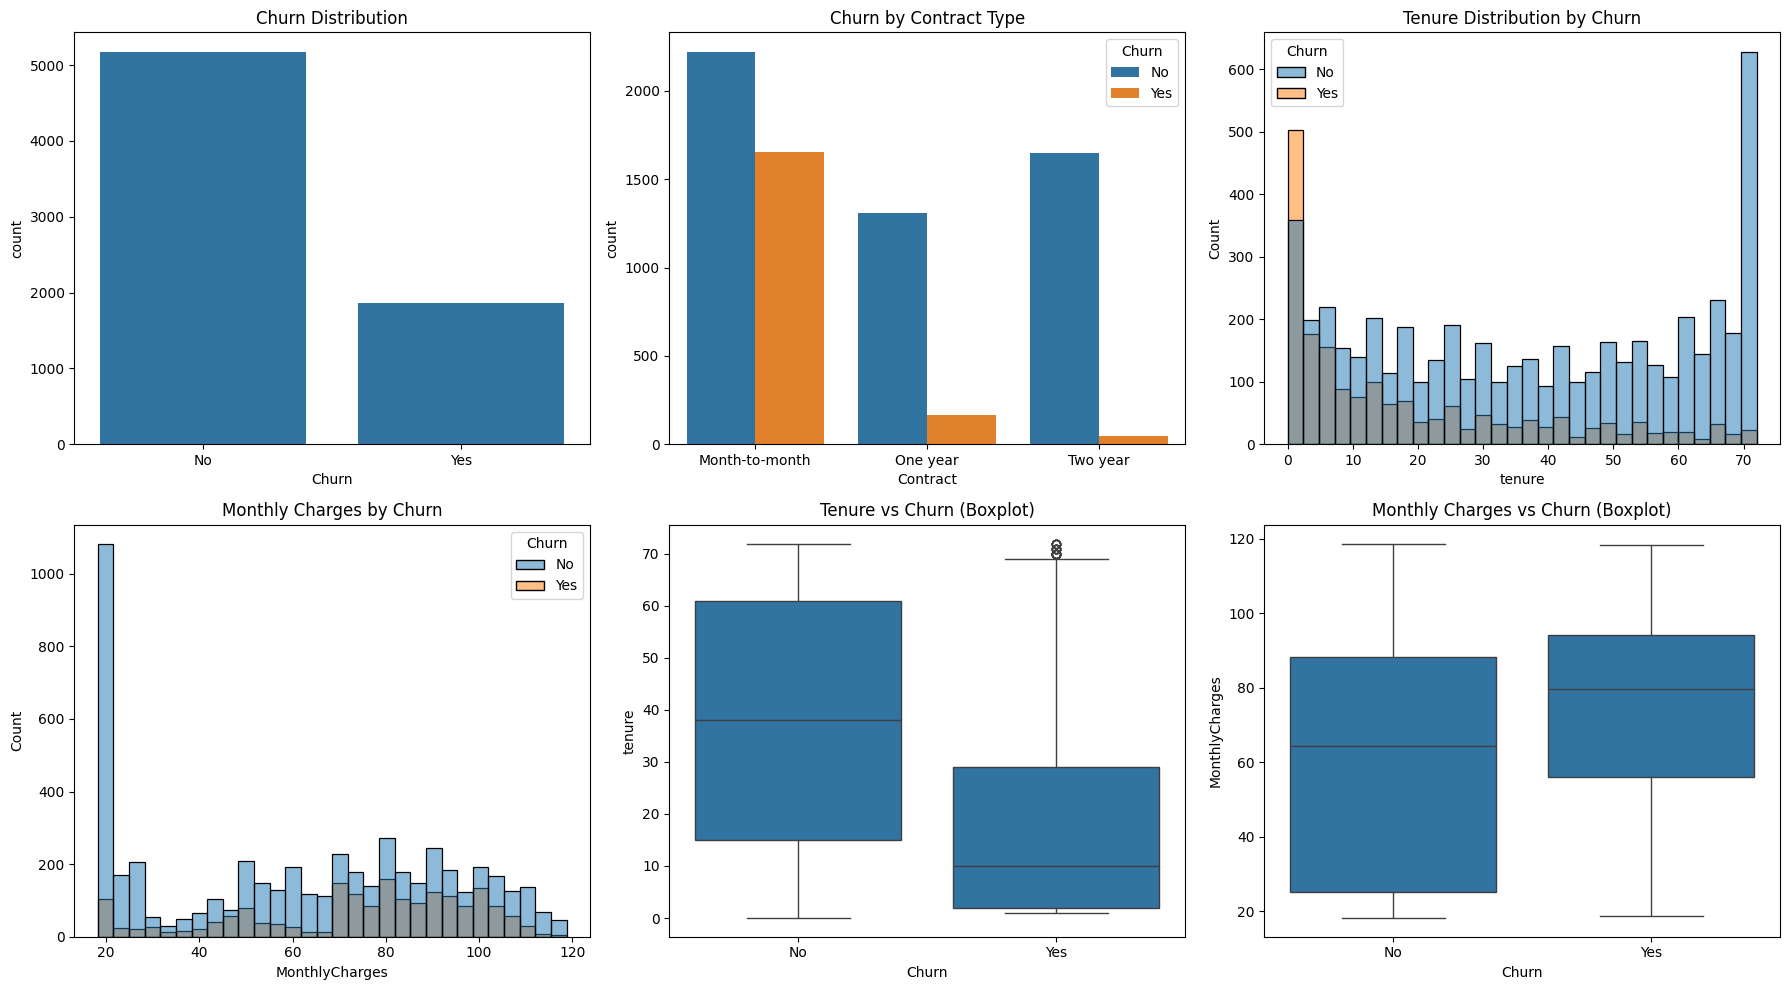

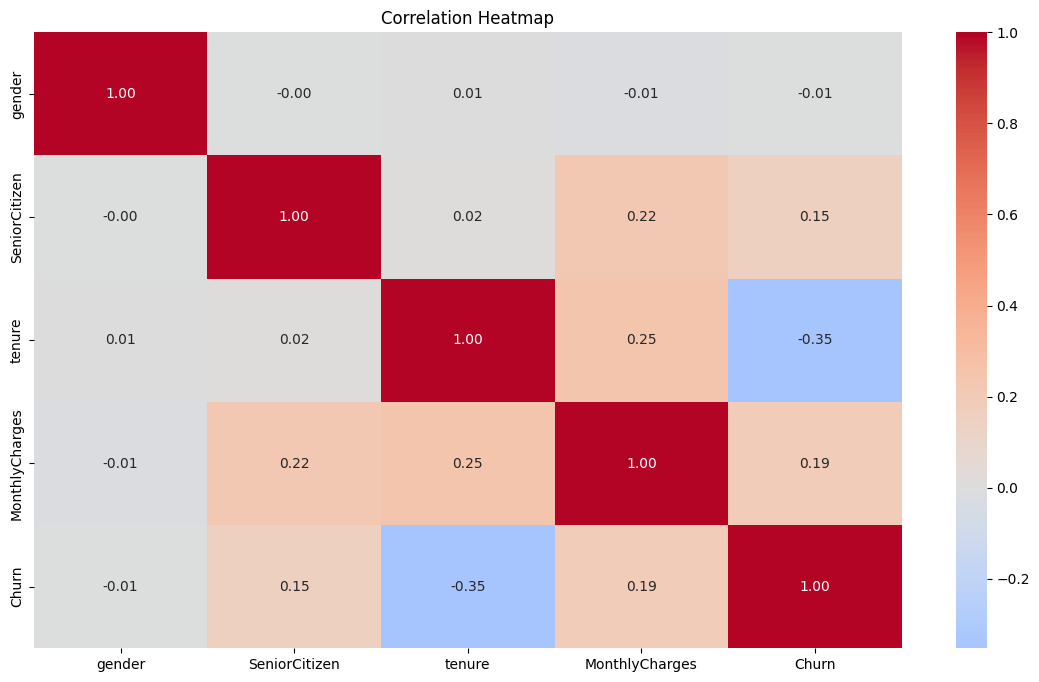

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Class balance
sns.countplot(data=df, x='Churn', ax=axes[0,0])
axes[0,0].set_title('Churn Distribution')

# 2. Contract vs Churn (categorical)
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0,1])
axes[0,1].set_title('Churn by Contract Type')

# 3. Tenure distribution (numeric)
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, ax=axes[0,2])
axes[0,2].set_title('Tenure Distribution by Churn')

# 4. MonthlyCharges distribution (numeric)
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30, ax=axes[1,0])
axes[1,0].set_title('Monthly Charges by Churn')

# 5. Boxplot — tenure vs churn
sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[1,1])
axes[1,1].set_title('Tenure vs Churn (Boxplot)')

# 6. Boxplot — charges vs churn
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1,2])
axes[1,2].set_title('Monthly Charges vs Churn (Boxplot)')

plt.tight_layout()
plt.show()

# 7. Correlation heatmap — AFTER encoding
# Convert binary columns first
df_encoded = df.copy()
df_encoded['Churn'] = df_encoded['Churn'].map({'No': 0, 'Yes': 1})
df_encoded['gender'] = df_encoded['gender'].map({'Male': 1, 'Female': 0})

plt.figure(figsize=(14, 8))
sns.heatmap(df_encoded.corr(numeric_only=True),
            annot=True, cmap='coolwarm',
            center=0, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [32]:
# --- Step 1: Fix TotalCharges dtype bug ---
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many nulls appeared after conversion
print("Nulls after fix:", df['TotalCharges'].isnull().sum())

# Fill those nulls with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# --- Step 2: Drop useless column ---
df.drop('customerID', axis=1, inplace=True)

# --- Step 3: Encode target variable ---
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

# --- Step 4: Separate binary vs multi-category columns ---
# Binary columns (Yes/No, Male/Female) → Label Encoding
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'MultipleLines', 'OnlineSecurity',
               'OnlineBackup', 'DeviceProtection', 'TechSupport',
               'StreamingTV', 'StreamingMovies']

# Multi-category columns → One Hot Encoding
multi_cols = ['InternetService', 'Contract', 'PaymentMethod']

# --- Step 5: Apply Label Encoding to binary cols ---
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# --- Step 6: Apply One Hot Encoding to multi cols ---
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

# --- Step 7: Split BEFORE scaling ---
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y      # keeps churn ratio same in train & test
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Churn ratio in train:", y_train.mean().round(2))
print("Churn ratio in test:", y_test.mean().round(2))

# --- Step 8: Scale AFTER splitting ---
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fit + transform on train
X_test = scaler.transform(X_test)        # ONLY transform on test




## ⚠️ Critical Rule — Why Scale After Split?

'''WRONG — scale first, then split
   → test data influences the scaler → data leakage

✅ CORRECT — split first, then scale
   → scaler only learns from training data
   → test data is truly unseen'''

Nulls after fix: 11
Train shape: (5634, 23)
Test shape: (1409, 23)
Churn ratio in train: 0.27
Churn ratio in test: 0.27


/var/folders/bc/0zjt7w692v93r3vvgk1stk5c0000gn/T/ipykernel_5568/2927809160.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


'WRONG — scale first, then split\n   → test data influences the scaler → data leakage\n\n✅ CORRECT — split first, then scale\n   → scaler only learns from training data\n   → test data is truly unseen'

In [33]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE only on training data
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# Verify balance
print("Before SMOTE:")
print(f"  No Churn: {sum(y_train == 0)}")
print(f"  Churn:    {sum(y_train == 1)}")

print("\nAfter SMOTE:")
print(f"  No Churn: {sum(y_train_res == 0)}")
print(f"  Churn:    {sum(y_train_res == 1)}")

Before SMOTE:
  No Churn: 4139
  Churn:    1495

After SMOTE:
  No Churn: 4139
  Churn:    4139


/Users/mayanktiwari/micromamba/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                             recall_score, roc_auc_score,
                             classification_report)

# --- Define all models ---
models = {
    'Logistic Regression (Baseline)': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',  # handles imbalance internally
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        scale_pos_weight=3,      # ratio of No/Yes = 5174/1869 ≈ 3
        eval_metric='logloss',
        random_state=42
    )
}

# --- Train and evaluate all models ---
results = {}

for name, model in models.items():
    # Train
    model.fit(X_train_res, y_train_res)

    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Store results
    results[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'F1 Score':  f1_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'AUC-ROC':   roc_auc_score(y_test, y_prob)
    }

    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(classification_report(y_test, y_pred))

# --- Summary table ---
print("\n📊 Model Comparison Summary:")
print(f"{'Model':<35} {'Accuracy':>9} {'F1':>7} {'Recall':>8} {'AUC':>7}")
print("-" * 70)
for name, metrics in results.items():
    print(f"{name:<35} {metrics['Accuracy']:>9.2f} "
          f"{metrics['F1 Score']:>7.2f} "
          f"{metrics['Recall']:>8.2f} "
          f"{metrics['AUC-ROC']:>7.2f}")

# Pick XGBoost as best model
best_model = models['XGBoost']

# Get predictions from best model
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("\nBest model selected: XGBoost ✅")
print(f"AUC: {roc_auc_score(y_test, y_prob):.4f}")




  Logistic Regression (Baseline)
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



/Users/mayanktiwari/micromamba/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/mayanktiwari/micromamba/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/mayanktiwari/micromamba/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/mayanktiwari/micromamba/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/mayanktiwari/micromamba/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise 


  Random Forest
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1035
           1       0.57      0.58      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.78      0.77      0.77      1409


  XGBoost
              precision    recall  f1-score   support

           0       0.88      0.76      0.82      1035
           1       0.52      0.72      0.60       374

    accuracy                           0.75      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.79      0.75      0.76      1409


📊 Model Comparison Summary:
Model                                Accuracy      F1   Recall     AUC
----------------------------------------------------------------------
Logistic Regression (Baseline)           0.74    0.62     0.80    0.84
Random Forest                            0.77    0.58     0.58    0.82
XGBoo

## 📌 What to Look For in Results

**Don't just look at accuracy.** Look at this priority order:
```
1. AUC-ROC  → overall model quality
2. Recall   → are we catching actual churners?
3. F1 Score → balance of precision and recall
4. Accuracy → least important for imbalanced data
```

For a churn problem, **Recall is the most business-critical metric** — missing a churner costs the company money. It's worse to miss a churner than to wrongly flag a loyal customer.

---

## Stage 6 — Evaluation

**Question 7:**

You run your models and get these results:
```
Logistic Regression → Accuracy: 0.75, AUC: 0.83
Random Forest       → Accuracy: 0.80, AUC: 0.85  
XGBoost             → Accuracy: 0.82, AUC: 0.87'''


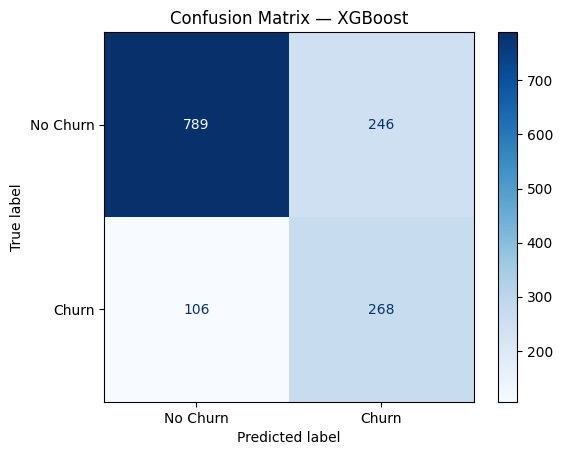

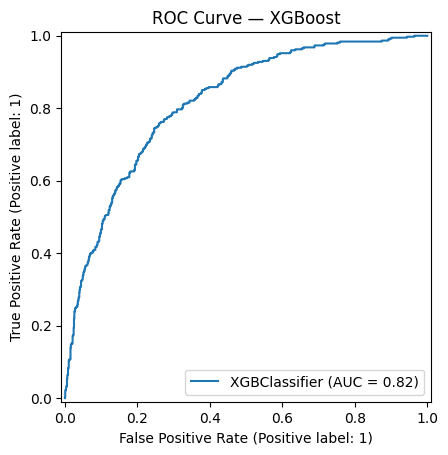

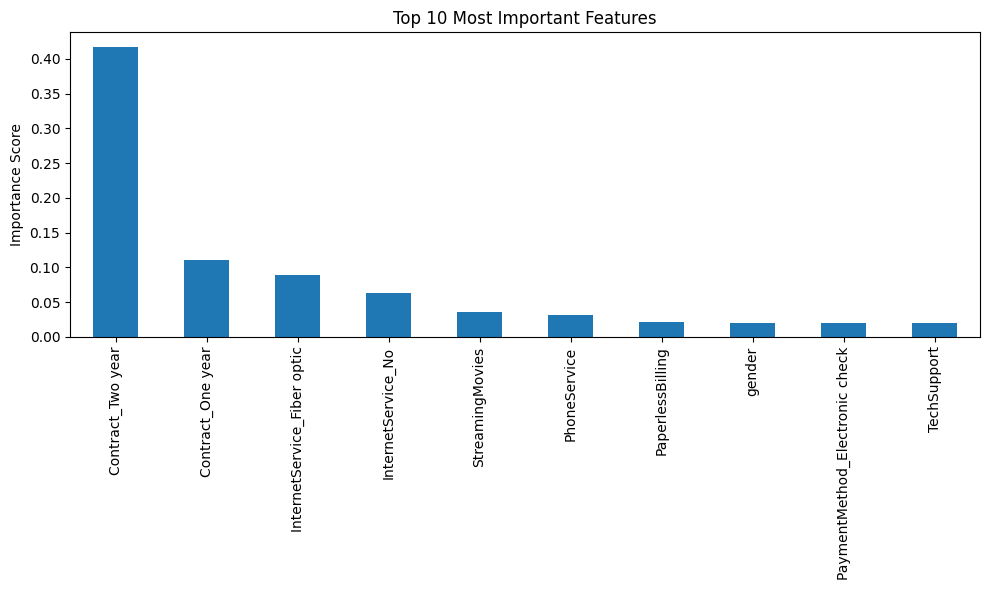


Top 5 features that predict churn:
Contract_Two year              0.417302
Contract_One year              0.111062
InternetService_Fiber optic    0.088767
InternetService_No             0.063233
StreamingMovies                0.036331
dtype: float32


In [35]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              RocCurveDisplay, roc_auc_score)

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — XGBoost')
plt.show()

# --- ROC Curve ---
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title('ROC Curve — XGBoost')
plt.show()

# --- Feature Importance ---
import pandas as pd
feat_importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_importance.head(10).plot(kind='bar')
plt.title('Top 10 Most Important Features')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 features that predict churn:")
print(feat_importance.head())

In [36]:
import joblib

# Save model and scaler
joblib.dump(best_model, '../models/model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("model.pkl saved ✅")
print("scaler.pkl saved ✅")

model.pkl saved ✅
scaler.pkl saved ✅
